## Real data for the poster
Ex vivo macaque (sub-M1), slice 42, 6 TEs × 8 b-values. Two-compartment fits at the left and right WM/GM boundary, then a three-compartment fit in frontal white matter.


In [1]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation




ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/mb4725/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/mb4725/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 566, in _log_error
    f.result()
  File "/Users/mb4725/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/mb4725/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/Users/mb4725/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 668, in get
    value = self._validate(obj, default)
  File "/Us

#### Build Y (noise-floor corrected, all brain voxels)


Slice 42: 3679 WM voxels
Background region: 1254 voxels

-- Run 1  (TE = 28.120 ms) --
  background: mean 5008, mean/std 5.05
  b=     0  ->  averaged  7 volumes,  noise floor    6178,  clipped  1.3%
  b=  1000  ->  averaged 12 volumes,  noise floor    5621,  clipped  1.2%
  b=  2500  ->  averaged 12 volumes,  noise floor    5262,  clipped  1.1%
  b=  5000  ->  averaged 12 volumes,  noise floor    5109,  clipped  1.3%
  b=  7500  ->  averaged 12 volumes,  noise floor    5024,  clipped  1.4%
  b= 11100  ->  averaged 32 volumes,  noise floor    4975,  clipped  1.8%
  b= 18100  ->  averaged 32 volumes,  noise floor    4923,  clipped  2.3%
  b= 25000  ->  averaged 32 volumes,  noise floor    4916,  clipped  2.6%

-- Run 2  (TE = 33.000 ms) --
  background: mean 4938, mean/std 5.93
  b=     0  ->  averaged  8 volumes,  noise floor    5668,  clipped  1.1%
  b=  1000  ->  averaged 12 volumes,  noise floor    5348,  clipped  1.1%
  b=  2500  ->  averaged 12 volumes,  noise floor    5164,  clip

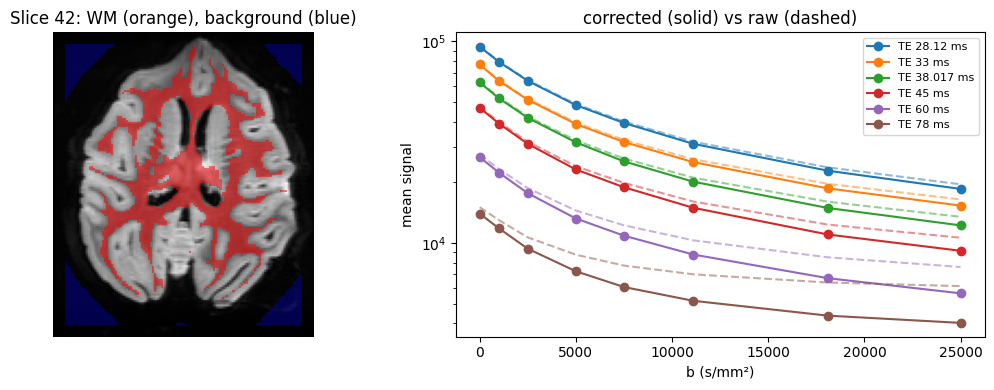

In [2]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra_est(F_est, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        2, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 5.8),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        image = axes[0, col].imshow(
            F_est[:, voxel].reshape(nD, nT2),
            origin="lower",
            aspect="auto",
            extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
        )
        axes[0, col].set_title(f"Estimated: voxel {voxel}")
        axes[0, col].set_xlabel("T2 (ms)")
        axes[0, col].set_ylabel("D")
        fig.colorbar(image, ax=axes[0, col], shrink=0.75)

        # The second row reports the component weights that form this spectrum.
        components = np.arange(W_est.shape[0])
        axes[1, col].bar(components, W_est[:, voxel], 0.5, color="tab:orange")
        axes[1, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")

    plt.show()

"""
Build the D-T2 signal matrix Y for ONE axial slice of sub-M1, using WM_mask_dwispace.nii.gz.

- Reads only the chosen slice from each run (low memory, fast)
- Removes the noise floor PER VOLUME, before averaging:
      A = sqrt(max(M^2 - mean(background^2), 0))
  For a multi-channel magnitude image E[M^2] = A^2 + 2N*sigma^2, and the mean of the
  squared background (no signal) estimates 2N*sigma^2 directly, so N does not need to be known.
- Averages volumes sharing the same b-value within each run (powder average)
- Y shape: (nTE * nB, V), rows ordered TE-major then b; acq_table gives (b, TE) per row
"""

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation

# ---------------------------------------------
# 0. CONFIGURATION
# ---------------------------------------------
DATA_DIR   = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque"
OUT_DIR    = os.path.join(DATA_DIR, "preprocessed")
MASK_PATH  = os.path.join(OUT_DIR, "WM_mask_dwispace.nii.gz")
BRAIN_PATH = os.path.join(DATA_DIR, "bet4animal_brainmask_f08_mask.nii.gz")
os.makedirs(OUT_DIR, exist_ok=True)

SLICE_IDX = 42    # axial (3rd axis) slice; 42 has the most WM voxels (3679)

TE_BY_RUN = {1: 28.12, 2: 33.0, 3: 38.017, 4: 45.0, 5: 60.0, 6: 78.0}
RUNS      = [1, 2, 3, 4, 5, 6]   # [2, 4, 5, 6] = single diffusion time only
#COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0])
COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0])
BVAL_TOL  = 50.0

NOISE_CORRECT = True   # False reproduces the old, uncorrected Y
BG_DILATE     = 10     # background = this many voxels away from the brain mask
BG_EDGE       = 5      # and this many voxels away from the image border

TE_vals = np.array([TE_BY_RUN[r] for r in RUNS])


# ---------------------------------------------
# 1. MASKS FOR THE SLICE
# ---------------------------------------------
mask_img   = nib.load(MASK_PATH)
mask_slice = mask_img.get_fdata()[:, :, SLICE_IDX] > 0
n_voxels   = int(mask_slice.sum())
print(f"Slice {SLICE_IDX}: {n_voxels} WM voxels")

brain_img = nib.load(BRAIN_PATH)
if brain_img.shape[:3] != mask_img.shape:
    raise ValueError(f"Brain mask grid {brain_img.shape[:3]} does not match WM mask {mask_img.shape}")
brain_slice = brain_img.get_fdata()[:, :, SLICE_IDX] > 0
bg_slice = ~binary_dilation(brain_slice, iterations=BG_DILATE)
bg_slice[:BG_EDGE] = bg_slice[-BG_EDGE:] = False
bg_slice[:, :BG_EDGE] = bg_slice[:, -BG_EDGE:] = False
print(f"Background region: {int(bg_slice.sum())} voxels")


# ---------------------------------------------
# 2. PER-RUN NOISE CORRECTION + SHELL AVERAGES ON THE SLICE
# ---------------------------------------------
def load_slice(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.nii.gz")
    img  = nib.load(path)
    if img.shape[:3] != mask_img.shape or not np.allclose(img.affine, mask_img.affine, atol=1e-3):
        raise ValueError(f"Run {run_idx} grid {img.shape[:3]} does not match mask {mask_img.shape}")
    return np.asarray(img.dataobj[:, :, SLICE_IDX, :], dtype=np.float32)   # (x, y, nvol)


def load_bvals(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.bval")
    return np.loadtxt(path).ravel()


rows, rows_raw, floor_rows, clipped_rows = [], [], [], []
for run_idx in RUNS:
    print(f"\n-- Run {run_idx}  (TE = {TE_BY_RUN[run_idx]:.3f} ms) --")
    vol   = load_slice(run_idx)                                  # (x, y, nvol)
    raw   = vol[brain_slice].astype(np.float64)                  # (V, nvol), all brain voxels (not only WM)
    bg    = vol[bg_slice].astype(np.float64)                     # (n_bg, nvol)
    bvals = load_bvals(run_idx)

    noise_sq = (bg ** 2).mean(axis=0)                            # (nvol,) = 2N*sigma^2 per volume
    print(f"  background: mean {bg.mean():.0f}, mean/std {bg.mean() / bg.std():.2f}")

    if NOISE_CORRECT:
        diff = raw ** 2 - noise_sq[None, :]
        clipped = diff < 0                                       # voxel/volume below the noise floor
        data = np.sqrt(np.maximum(diff, 0))
    else:
        clipped = np.zeros_like(raw, dtype=bool)
        data = raw

    for bval in COMMON_BVALS:
        sel = np.abs(bvals - bval) <= BVAL_TOL
        if not sel.any():
            raise ValueError(f"No volumes for b={bval:.0f} in run {run_idx}")
        rows.append(data[:, sel].mean(axis=1))
        rows_raw.append(raw[:, sel].mean(axis=1))
        floor_rows.append(np.sqrt(noise_sq[sel].mean()))
        clipped_rows.append(clipped[:, sel].mean())
        print(f"  b={bval:>6.0f}  ->  averaged {sel.sum():2d} volumes,"
              f"  noise floor {floor_rows[-1]:7.0f},  clipped {100 * clipped_rows[-1]:4.1f}%")


# ---------------------------------------------
# 3. BUILD Y AND SAVE
# ---------------------------------------------
nB, nTE = len(COMMON_BVALS), len(RUNS)
Y     = np.stack(rows)                                                    # (nTE*nB, V)
Y_raw = np.stack(rows_raw)
acq = np.column_stack([np.tile(COMMON_BVALS, nTE), np.repeat(TE_vals, nB)])  # (b, TE)
voxel_xy = np.argwhere(brain_slice)                                       # to map columns back

tag = f"slice{SLICE_IDX}_brain"   # separate files, so the WM-only ones are not overwritten
suffix = "_nc" if NOISE_CORRECT else ""
np.save(os.path.join(OUT_DIR, f"Y_{tag}{suffix}.npy"),          Y)
np.save(os.path.join(OUT_DIR, f"noise_floor_{tag}.npy"),        np.array(floor_rows))   # sqrt(2N*sigma^2) per row
np.save(os.path.join(OUT_DIR, f"acq_table_{tag}.npy"),          acq)
np.save(os.path.join(OUT_DIR, f"voxel_xy_{tag}.npy"),           voxel_xy)
np.save(os.path.join(OUT_DIR, "TE_vals.npy"),                   TE_vals)
np.save(os.path.join(OUT_DIR, "bvals_common.npy"),              COMMON_BVALS)
print(f"\nSaved Y_{tag}{suffix}.npy, shape {Y.shape}  ({nTE} TEs x {nB} b-values, {Y.shape[1]} voxels)")


# ---------------------------------------------
# 4. SANITY CHECKS
# ---------------------------------------------
print(f"Any NaN: {np.isnan(Y).any()}   Any Inf: {np.isinf(Y).any()}")
print(f"Worst row: {100 * max(clipped_rows):.1f}% of voxel-volumes clipped at 0 "
      "(more than a few % means the correction is unreliable for that row)")

for label, M in [("raw", Y_raw), ("corrected", Y)]:
    s0 = M[0::nB].mean(axis=1)
    T2_mono = -1 / np.polyfit(TE_vals, np.log(s0), 1)[0]
    print(f"{label:>9}: mean b=0 per TE {[round(float(s)) for s in s0]},  mono-exp T2 ~ {T2_mono:.1f} ms")
    if np.any(np.diff(s0) > 0):
        print(f"! {label}: b=0 signal increases with TE somewhere: check scaling between runs")

b0_slice = load_slice(RUNS[0])[..., np.abs(load_bvals(RUNS[0])) <= BVAL_TOL].mean(-1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(b0_slice.T, cmap="gray", origin="lower")
ax[0].imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.5, origin="lower")
ax[0].imshow(np.ma.masked_where(~bg_slice.T, bg_slice.T), cmap="winter", alpha=0.3, origin="lower")
ax[0].set_title(f"Slice {SLICE_IDX}: WM (orange), background (blue)"); ax[0].axis("off")
for i, te in enumerate(TE_vals):
    line, = ax[1].semilogy(COMMON_BVALS, Y[i * nB:(i + 1) * nB].mean(1), "o-", label=f"TE {te:g} ms")
    ax[1].semilogy(COMMON_BVALS, Y_raw[i * nB:(i + 1) * nB].mean(1), "--", color=line.get_color(), alpha=0.5)
ax[1].set_xlabel("b (s/mm²)"); ax[1].set_ylabel("mean signal")
ax[1].set_title("corrected (solid) vs raw (dashed)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


#### WM/GM boundary regions: fit + poster figure


b values  [ 0.   1.   2.5  5.   7.5 11.1 18.1 25. ] 

TE values  [28.12  33.    38.017 45.    60.    78.   ] 

background mean/std: 2.71254

===== Region left: cx, cy = 33, 51 =====
Selected 40 voxels: 20 in WM, 20 outside WM
Y shape  (48, 40) 



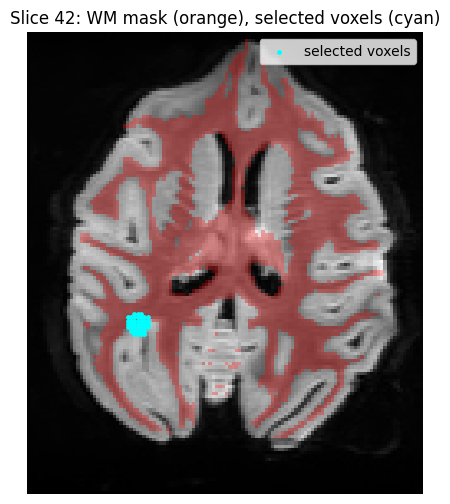

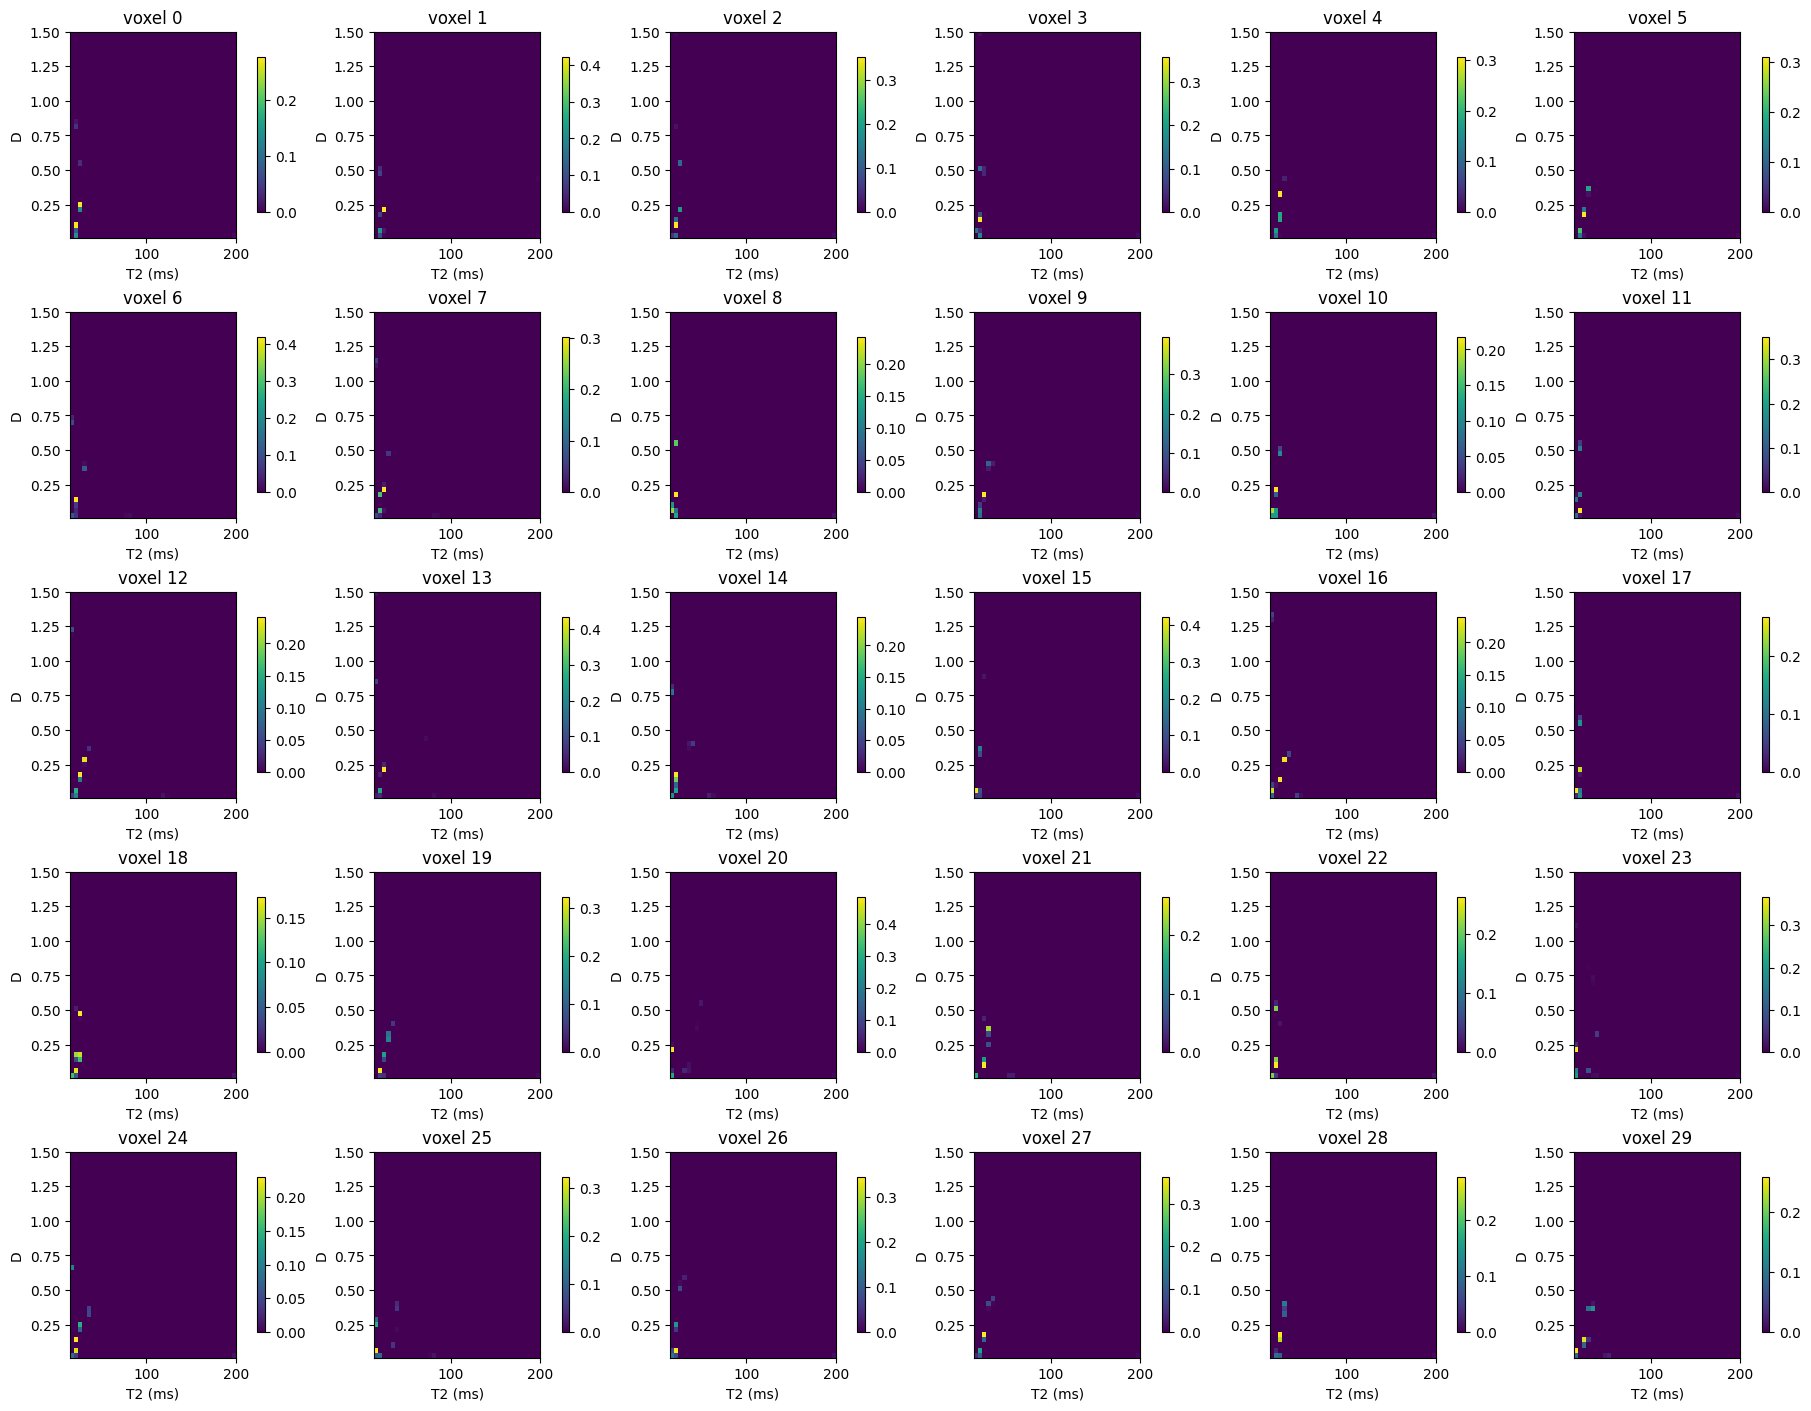

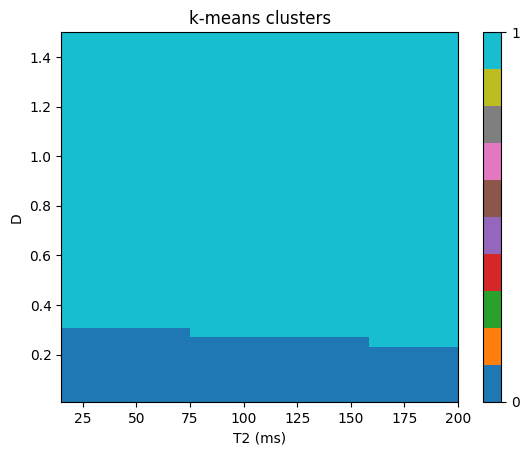

cluster 0: D = 0.102, T2 = 21.8 ms
cluster 1: D = 0.501, T2 = 24.7 ms


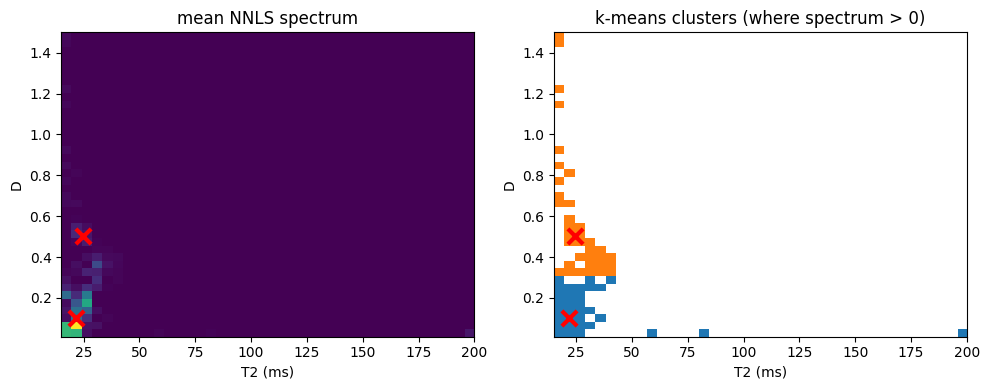

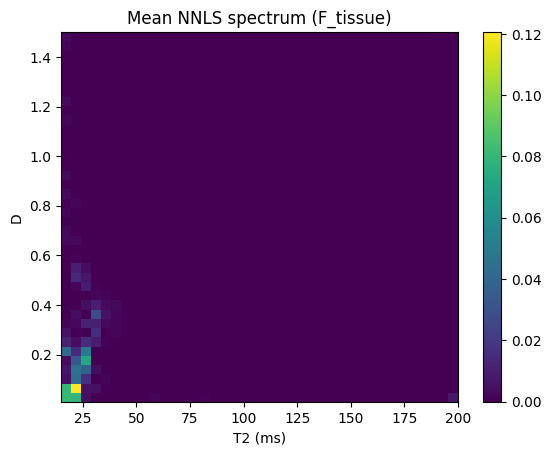

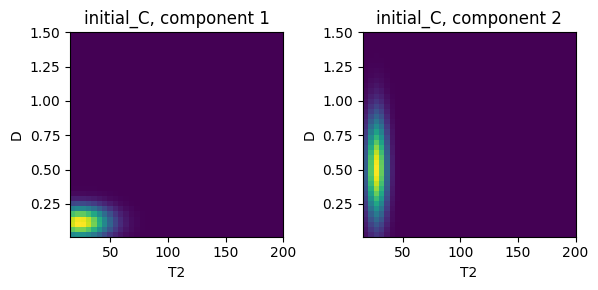



iter 0: loss=1031.7520, fit_err=1084.841511, sigma2=0.565022
iter 100: loss=1097.5502, fit_err=322.706953, sigma2=0.168077
iter 200: loss=1091.8327, fit_err=322.289249, sigma2=0.167859
iter 300: loss=1091.8017, fit_err=322.216310, sigma2=0.167821
iter 400: loss=1091.8720, fit_err=322.161215, sigma2=0.167792
iter 500: loss=1091.8468, fit_err=322.158490, sigma2=0.167791
iter 600: loss=1091.8436, fit_err=322.156604, sigma2=0.167790
iter 700: loss=1091.8408, fit_err=322.156274, sigma2=0.167790
iter 800: loss=1091.8458, fit_err=322.154509, sigma2=0.167789
iter 900: loss=1091.8481, fit_err=322.153701, sigma2=0.167788
dirichlet prior: estimated C


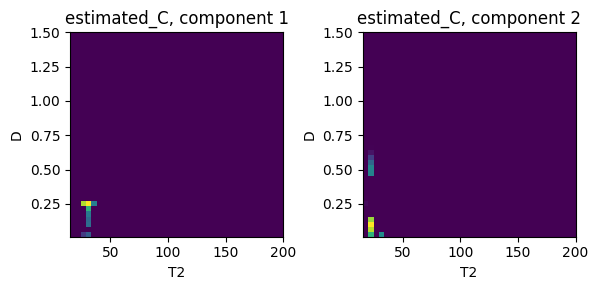

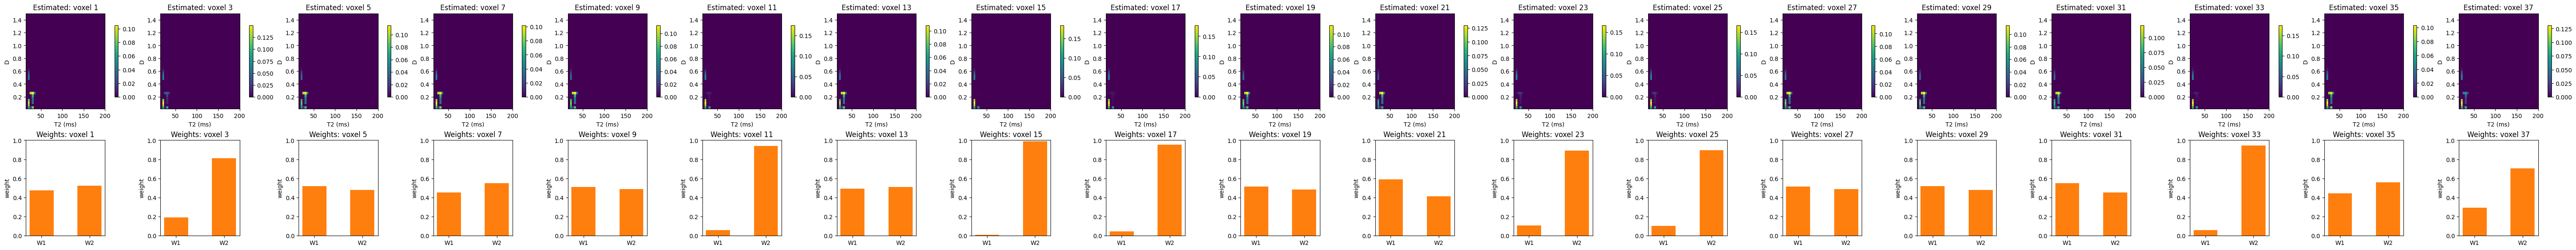

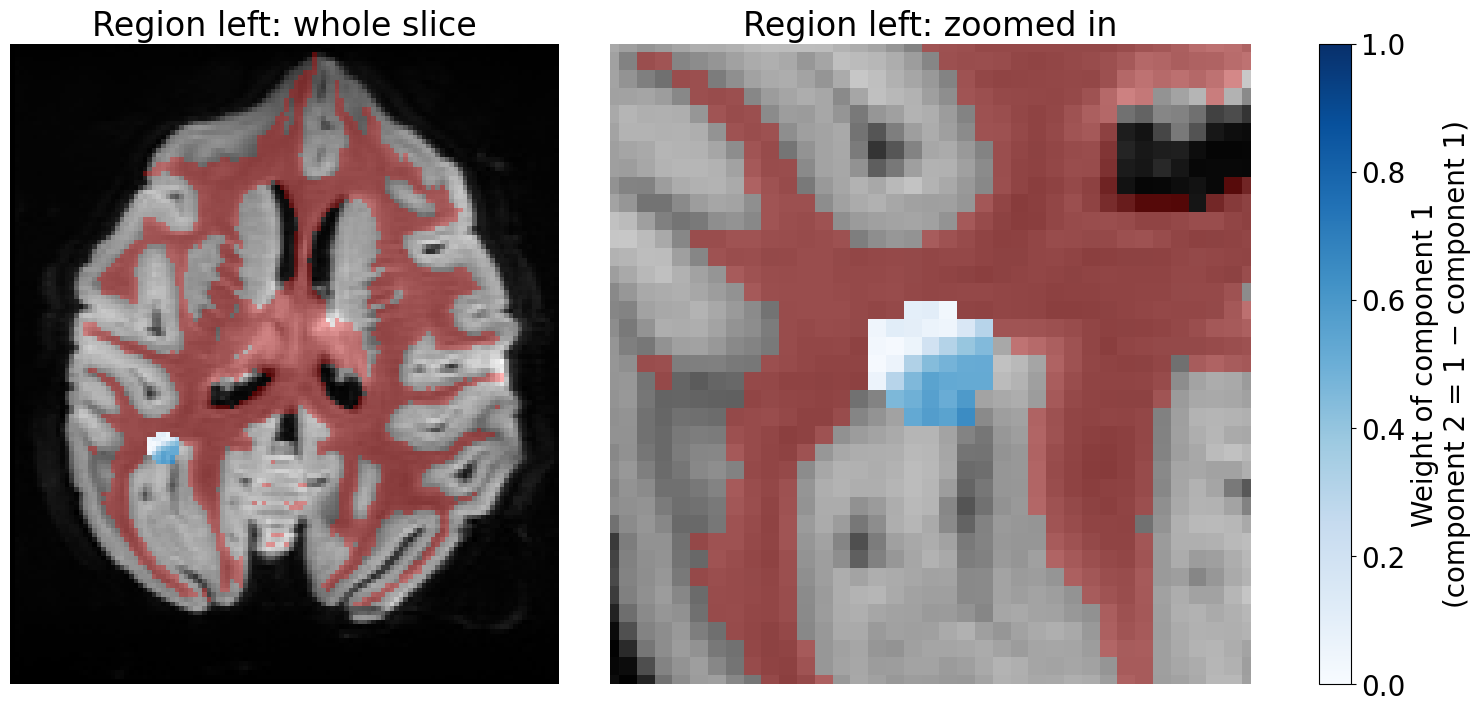

region left, component 1: mean weight in WM 0.12 (20 voxels), outside WM 0.51 (20 voxels)
region left, component 2: mean weight in WM 0.88 (20 voxels), outside WM 0.49 (20 voxels)

===== Region right: cx, cy = 86, 60 =====
Selected 40 voxels: 18 in WM, 22 outside WM
Y shape  (48, 40) 



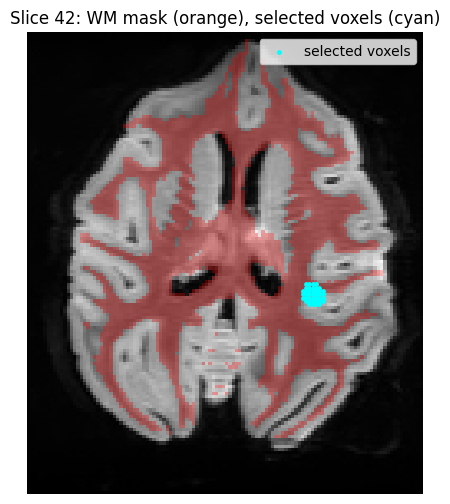

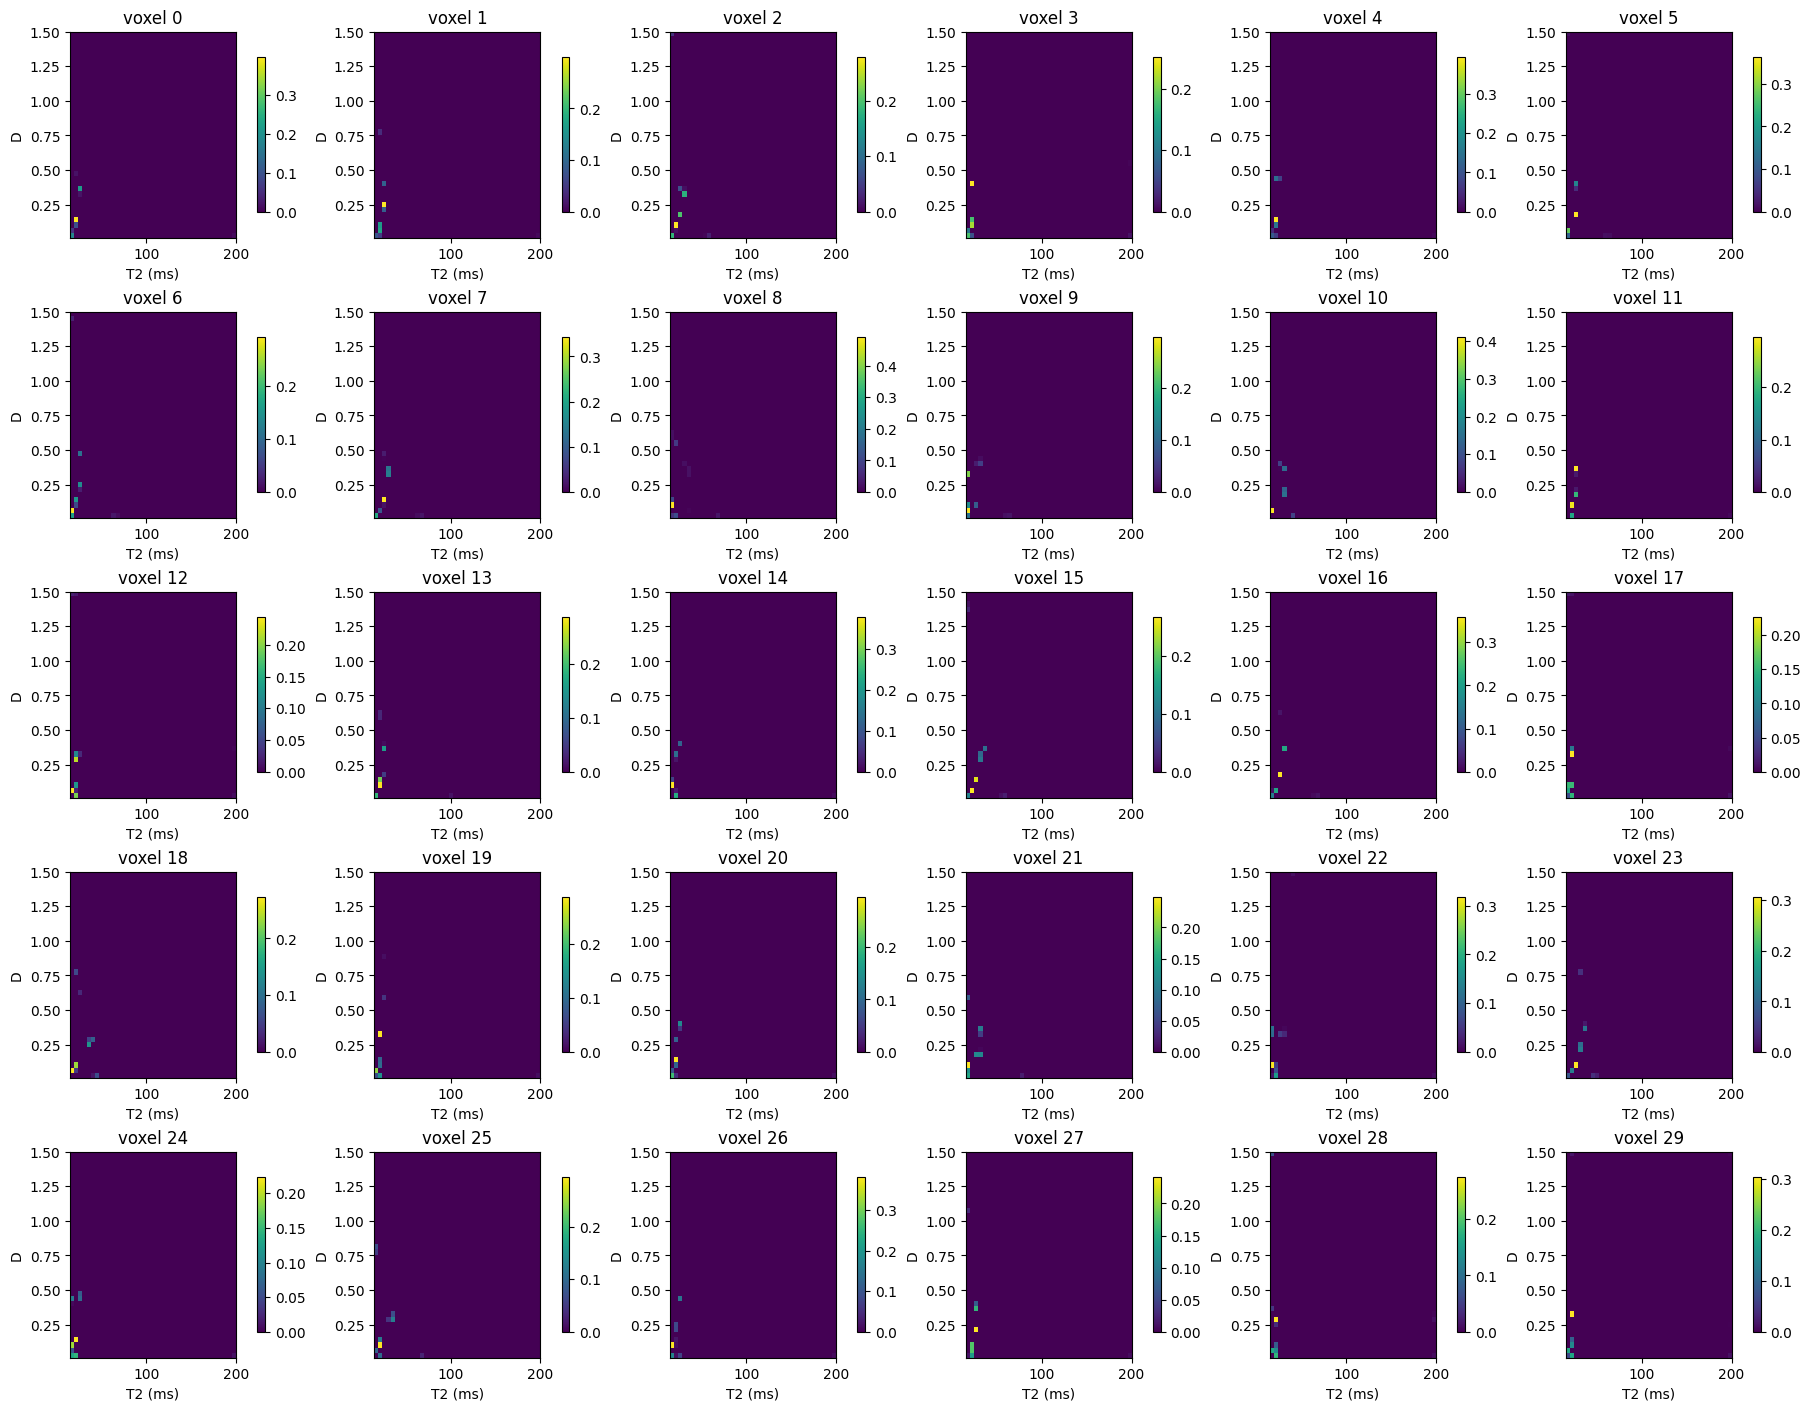

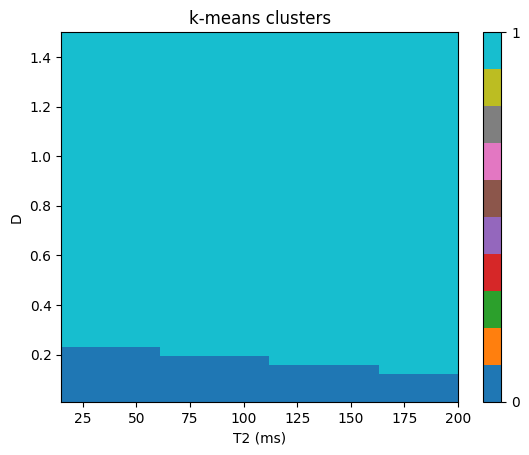

cluster 0: D = 0.073, T2 = 20.8 ms
cluster 1: D = 0.384, T2 = 24.3 ms


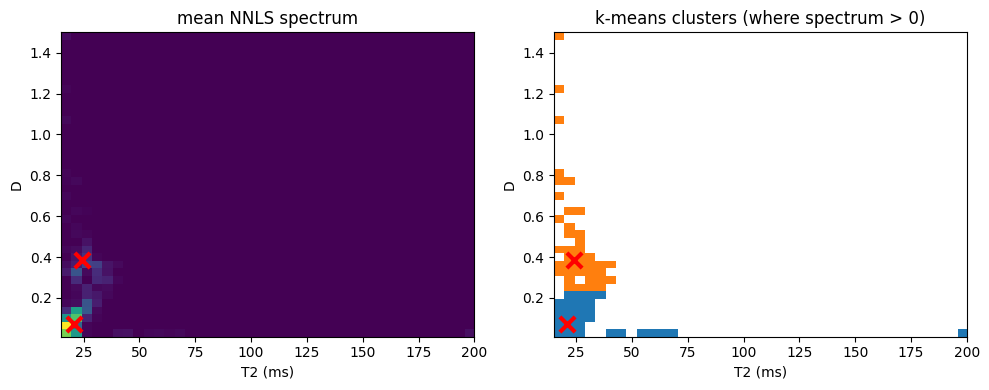

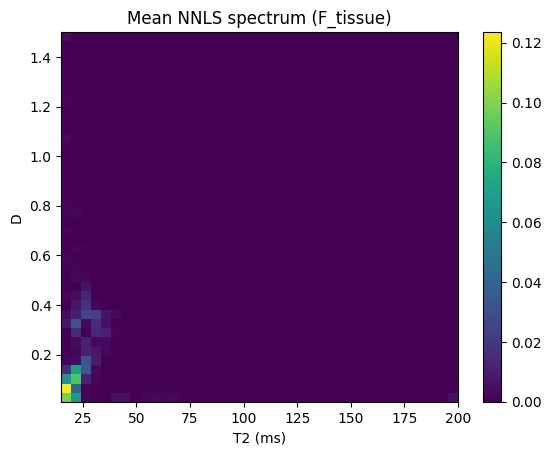

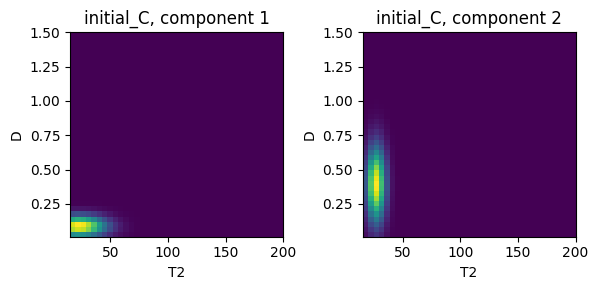



iter 0: loss=1051.6457, fit_err=1153.070622, sigma2=0.600558
iter 100: loss=1151.3618, fit_err=510.467096, sigma2=0.265868
iter 200: loss=1147.4470, fit_err=510.369756, sigma2=0.265818
iter 300: loss=1147.1540, fit_err=510.458296, sigma2=0.265864
iter 400: loss=1147.1157, fit_err=510.476308, sigma2=0.265873
iter 500: loss=1147.1160, fit_err=510.476066, sigma2=0.265873
iter 600: loss=1147.1158, fit_err=510.476134, sigma2=0.265873
iter 700: loss=1147.1126, fit_err=510.477797, sigma2=0.265874
iter 800: loss=1147.0990, fit_err=510.484941, sigma2=0.265878
iter 900: loss=1147.1006, fit_err=510.484095, sigma2=0.265877
dirichlet prior: estimated C


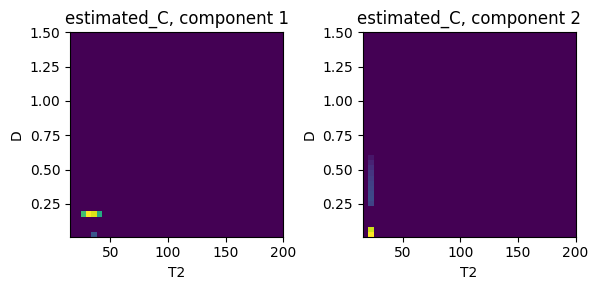

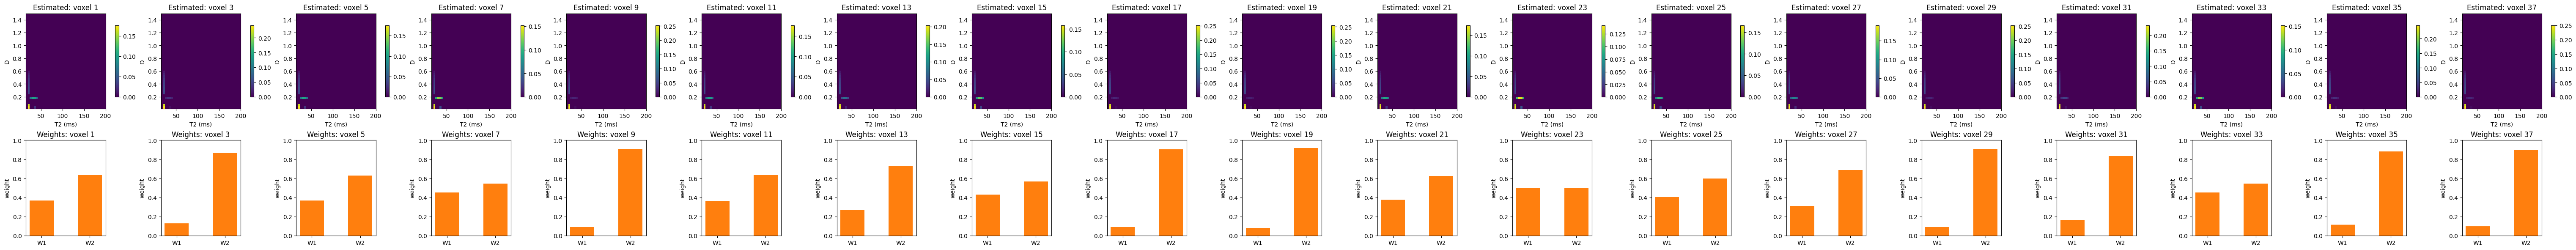

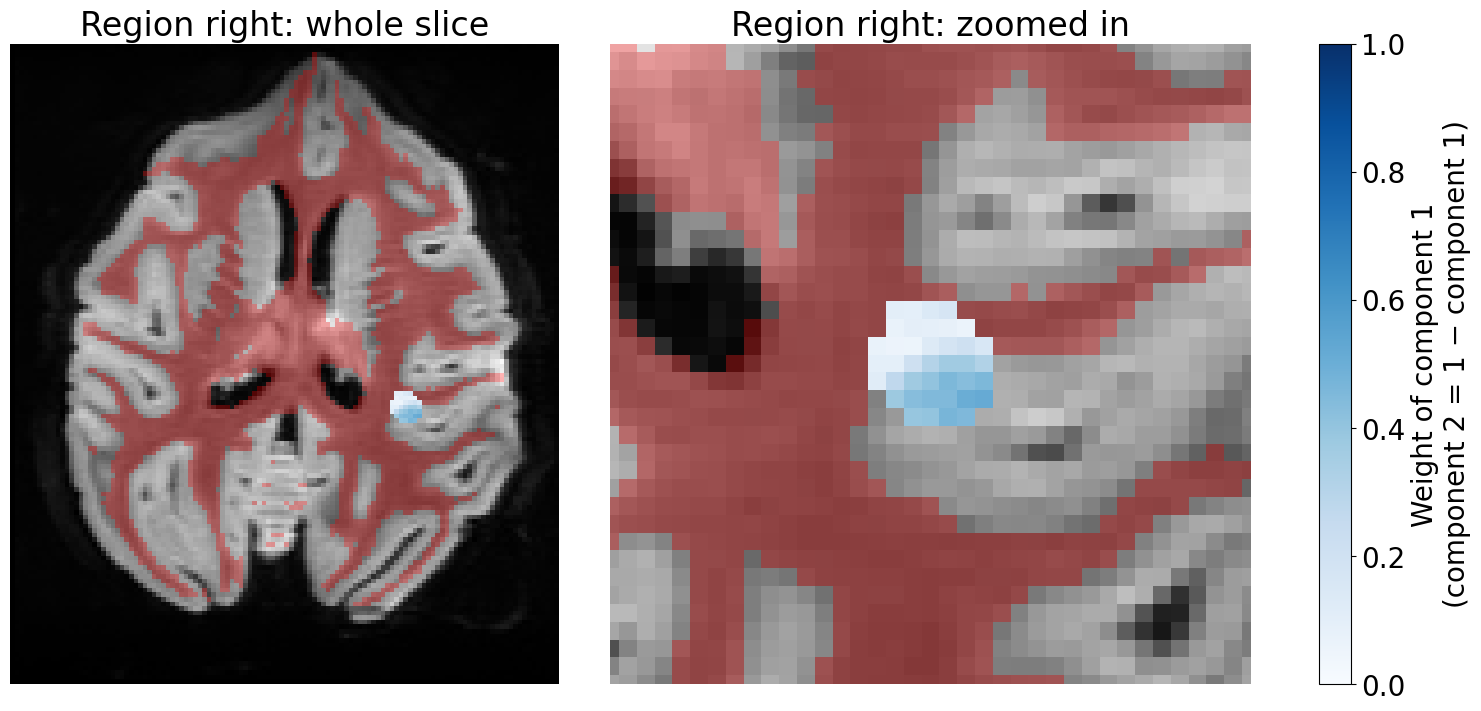

region right, component 1: mean weight in WM 0.10 (18 voxels), outside WM 0.39 (22 voxels)
region right, component 2: mean weight in WM 0.90 (18 voxels), outside WM 0.61 (22 voxels)


In [3]:
n_voxels=40
#Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 2, 300.0, 20, 20  
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 15.0, 1.5, 200.0, 40, 40  
voxels_to_show = list(range(1, n_voxels-2, 2))   # 1, 3, ..., 57

# the regions, fitted one after the other; everything from each run is kept in fits[region]
# left/right straddle the WM boundary, cc is white matter only (corpus callosum)
regions = {"left": (33, 51), "right": (86, 60)}   # ROI centre (x, y) in voxels, read off the map
fits = {}

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
Y_all = np.load(f"{OUT}/Y_slice42_brain_nc.npy")             # (nTE*nB, V), all brain voxels
acq = np.load(f"{OUT}/acq_table_slice42_brain.npy")   # columns: b [s/mm²], TE [ms]
voxel_xy_all = np.load(f"{OUT}/voxel_xy_slice42_brain.npy")

b_list = acq[:, 0] / 1000.0    # s/mm² -> ms/µm² (same units as D)
TE_list = acq[:, 1]
b_vals = np.unique(b_list) 
TE_vals = np.unique(TE_list)
print("b values ", b_vals, "\n")
print("TE values ", TE_vals, "\n")

# Define fitting parameters
K=2; # Number of compartments
R=10   # Rank for SVD

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2);
# Create A matrix from the real acquisition (rows match Y)
A = np.exp(-np.outer(b_list, D)) * np.exp(-np.outer(TE_list, 1.0 / T2));

# reorder rows b-major (b outer, TE inner), like create_A_matrix's grid
order = np.lexsort((TE_list, b_list))
A = A[order]

b_list, TE_list = b_list[order], TE_list[order]

U, s, Vmat = apply_SVD_to_A(A, R)

bg_vals = load_slice(1)[bg_slice][:, np.abs(load_bvals(1)) <= BVAL_TOL].ravel()
print("background mean/std:", bg_vals.mean() / bg_vals.std())

from sklearn.cluster import KMeans

for region, (cx, cy) in regions.items():
    print(f"\n===== Region {region}: cx, cy = {cx}, {cy} =====")
    near = np.argsort(np.hypot(voxel_xy_all[:, 0] - cx, voxel_xy_all[:, 1] - cy))[:n_voxels]
    Y, voxel_xy = Y_all[:, near], voxel_xy_all[near] 
    is_wm = mask_slice[voxel_xy[:, 0], voxel_xy[:, 1]]   # check the selected voxels against the WM mask
    print(f"Selected {len(voxel_xy)} voxels: {is_wm.sum()} in WM, {(~is_wm).sum()} outside WM")
    print("Y shape ", Y.shape, "\n")

    Y = Y / np.median(Y[0]) * 30   # scale so M0 ≈ 300, like the simulations
    Y = Y[order]                   # same row order as A
    V=Y.shape[1]; # Number of voxels

    plt.figure(figsize=(6, 6))
    plt.imshow(b0_slice.T, cmap="gray", origin="lower")
    plt.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
    plt.scatter(voxel_xy[:, 0], voxel_xy[:, 1], s=6, c="cyan", label="selected voxels")
    plt.title(f"Slice {SLICE_IDX}: WM mask (orange), selected voxels (cyan)")
    plt.legend(loc="upper right"); plt.axis("off"); plt.show()

    spectra = []
    for v in range(V):
        f, _ = nnls(A, Y[:, v])
        spectra.append(f / f.sum() if f.sum() > 0 else f)

    fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
    for v, ax in enumerate(axes.ravel()[:V]):
        im = ax.imshow(spectra[v].reshape(nD, nT2), origin="lower", aspect="auto",
                       extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
        ax.set(title=f"voxel {v}", xlabel="T2 (ms)", ylabel="D")
        fig.colorbar(im, ax=ax, shrink=0.75)
    plt.show()

    tissue_spectrum = np.mean(spectra, axis=0)
    tissue_spectrum /= tissue_spectrum.sum()

    D_mesh, T2_mesh = np.meshgrid(D_vals, T2_vals, indexing='ij')
    grid_points = np.column_stack([
        (D_mesh.ravel() - Dmin) / (Dmax - Dmin),
        (T2_mesh.ravel() - T2min) / (T2max - T2min),
    ])
    tissue_spectrum[tissue_spectrum < 0.01 * tissue_spectrum.max()] = 0
    tissue_spectrum /= tissue_spectrum.sum()

    kmeans = KMeans(n_clusters=K, n_init=10, random_state=0)
    kmeans.fit(grid_points, sample_weight=tissue_spectrum)
    labels = kmeans.labels_.reshape(nD, nT2)

    plt.imshow(labels, origin="lower", aspect="auto", cmap="tab10",
               extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
    plt.xlabel("T2 (ms)"); plt.ylabel("D"); plt.title("k-means clusters")
    plt.colorbar(ticks=range(K)); plt.show()

    F_mean = tissue_spectrum.reshape(nD, nT2)
    ext = [T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(F_mean, origin="lower", aspect="auto", extent=ext)
    axes[0].set(title="mean NNLS spectrum", xlabel="T2 (ms)", ylabel="D")
    axes[1].imshow(np.ma.masked_where(F_mean < 1e-3 * F_mean.max(), labels),
                   origin="lower", aspect="auto", extent=ext, cmap="tab10", vmin=0, vmax=9)
    axes[1].set(title="k-means clusters (where spectrum > 0)", xlabel="T2 (ms)", ylabel="D")

    for i in range(K):
        idxD, idxT2 = np.nonzero(labels == i)
        w = F_mean[idxD, idxT2]
        if w.sum() <= 0:
            continue   # empty cluster: the function falls back to the grid middle
        D_c = np.sum(D_vals[idxD] * w) / w.sum()
        T2_c = np.sum(T2_vals[idxT2] * w) / w.sum()
        print(f"cluster {i}: D = {D_c:.3f}, T2 = {T2_c:.1f} ms")
        for ax in axes:
            ax.scatter(T2_c, D_c, marker="x", s=120, linewidths=3, color="red")
    plt.tight_layout(); plt.show()

    rng=np.random.default_rng(0)
    # Dirichlet prior on the weights, constrained C (non-negative, simplex on the D–T2 grid)
    priors = {
        "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    }

    Y_dirichlet = Y

    # Set intial conditions
    C0_dirichlet, F_tissue, *_ = define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2,min_fraction=0.01,return_diagnostics=True)
    F_tissue = F_tissue.reshape(nD, nT2)

    Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat)

    M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    # F_tissue is the mean NNLS spectrum over all voxels (one nD x nT2 map), so plot it as one image
    plt.imshow(F_tissue, origin="lower", aspect="auto",
               extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
    plt.xlabel("T2 (ms)"); plt.ylabel("D"); plt.title("Mean NNLS spectrum (F_tissue)"); plt.colorbar(); plt.show()

    # noise level from the residual of the initial fit (no ground-truth sigma)
    sigma2_init = np.mean((Y_dirichlet - (U @ Csmall0_dirichlet @ W0_dirichlet) * M0_init_dirichlet) ** 2)

    show_canonical_spectra([('initial_C', C0_dirichlet)])
    print("\n")

    results = {}
    for name, kwargs in priors.items():
        # C is optimised on the physical grid, so it starts from C0 (not Csmall0) and comes back as C directly
        W_est_dirichlet, _, C_est_dirichlet, *_ = run_constrained_optimisation(
            Y_dirichlet, U, s, Vmat, C0_dirichlet.copy(), M0_init_dirichlet, K=K, n_iter=1000,
            sigma2=sigma2_init, lam=1e-2, alpha=1.0, W=W0_dirichlet.copy(),
            update_W_flag=True, update_C_flag=True, update_M0_flag=True, update_sigma2_flag=True,
            m0_prior=M0_init_dirichlet, m0_prior_sigma=3, alpha_update_start=5,
            c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
            verbose_every=100, **kwargs)
        print(f"{name} prior: estimated C")
        show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
        F_est = C_est_dirichlet @ W_est_dirichlet
        show_voxelwise_spectra_est(F_est, W_est_dirichlet, voxels_to_show)
        results[name] = (C_est_dirichlet.copy(), W_est_dirichlet.copy())

    # keep everything from this region, so the next region does not overwrite it
    C_res, W_res = results["dirichlet"]
    fits[region] = dict(cx=cx, cy=cy, Y=Y, voxel_xy=voxel_xy, is_wm=is_wm, C0=C0_dirichlet, C=C_res, W=W_res)

    # Map the weights back onto the brain: the fitted voxels are painted in blue by the
    # weight of component 1 (K = 2, so component 2 = 1 - component 1; left: whole slice, right: zoomed in)
    zoom = 15   # voxels shown around the ROI in the zoomed panel
    weight_map = np.full(mask_slice.shape, np.nan)          # NaN = not fitted, left see-through
    weight_map[voxel_xy[:, 0], voxel_xy[:, 1]] = W_res[0]
    with plt.rc_context({"font.size": 20}):
        fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
        for ax in axes:
            ax.imshow(b0_slice.T, cmap="gray", origin="lower")
            ax.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
            im = ax.imshow(np.ma.masked_invalid(weight_map.T), cmap="Blues", vmin=0, vmax=1,
                           origin="lower", interpolation="nearest", alpha=1)
            ax.axis("off")
        axes[0].set_title(f"Region {region}: whole slice")
        axes[1].set_title(f"Region {region}: zoomed in")
        axes[1].set_xlim(voxel_xy[:, 0].min() - zoom, voxel_xy[:, 0].max() + zoom)
        axes[1].set_ylim(voxel_xy[:, 1].min() - zoom, voxel_xy[:, 1].max() + zoom)
        fig.colorbar(im, ax=axes, fraction=0.046, label="Weight of component 1\n(component 2 = 1 − component 1)")
        fig.savefig(f"poster_brain_component_weights_{region}.png", dpi=300, bbox_inches="tight")
        plt.show()

    for k in range(K):
        line = f"region {region}, component {k + 1}: mean weight in WM {W_res[k, is_wm].mean():.2f} ({is_wm.sum()} voxels)"
        if (~is_wm).any():
            line += f", outside WM {W_res[k, ~is_wm].mean():.2f} ({(~is_wm).sum()} voxels)"
        print(line)


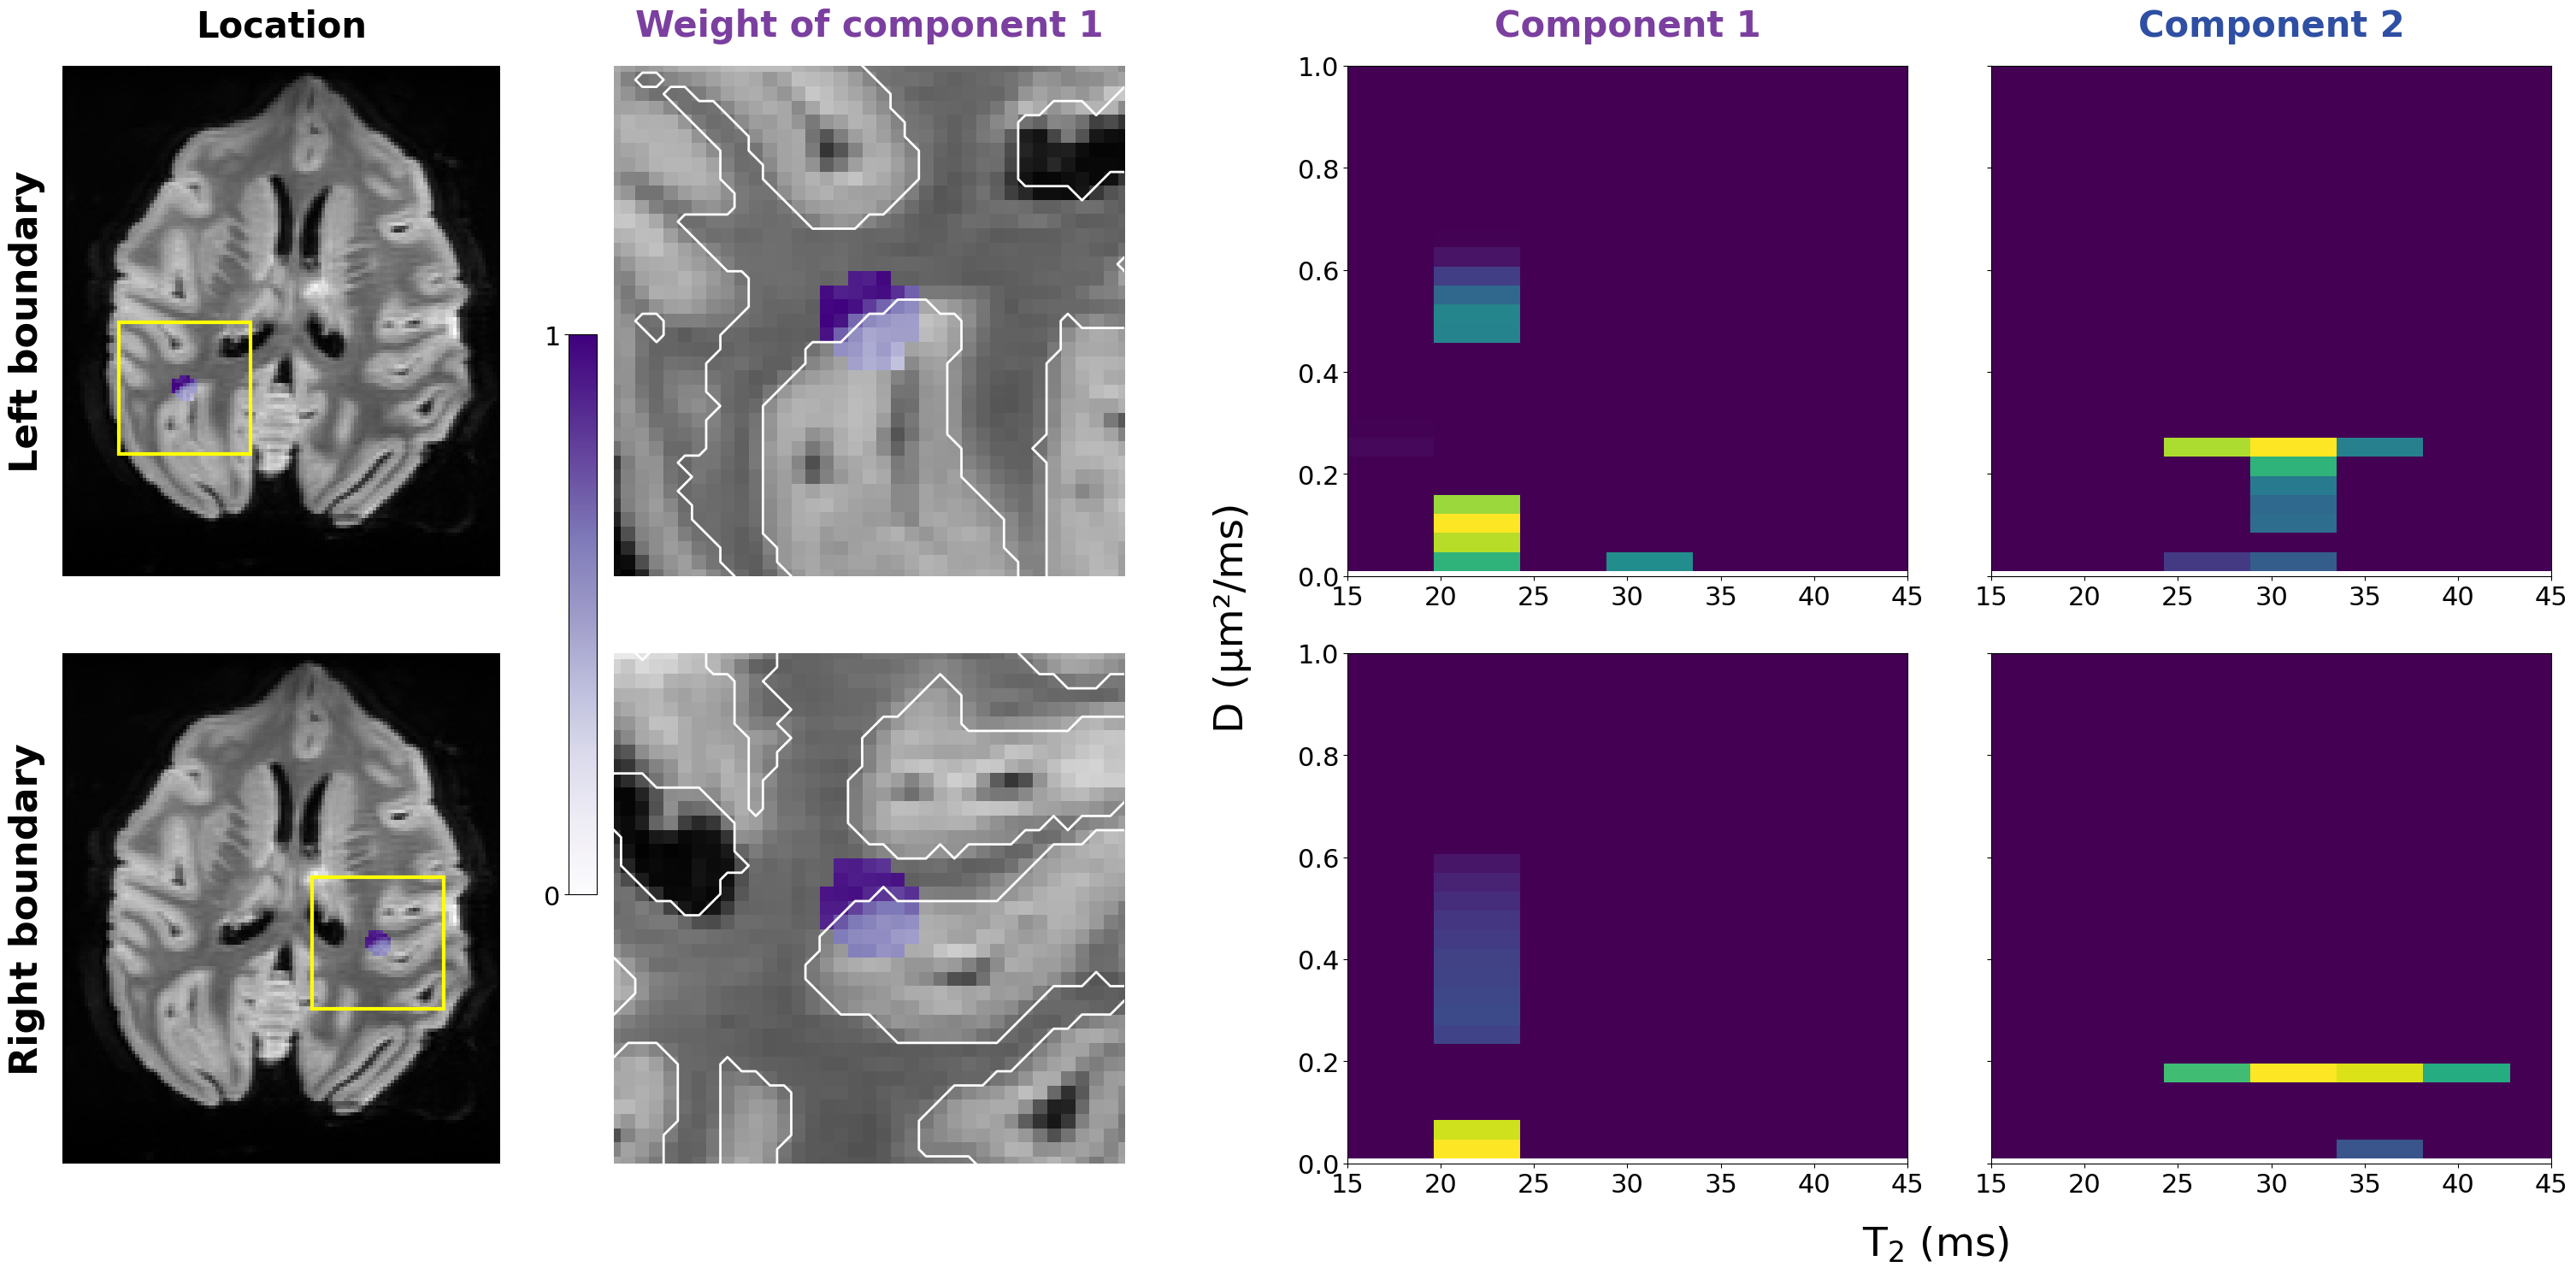

In [4]:
# Poster figure, real data: WM/GM boundary regions only
from matplotlib.patches import Rectangle

fs = 26
zoom = 15
T2_show = (15, 45)
D_show = (0, 1.0)
show = ["left", "right"]                       # boundary regions only
COMP_COLS = ["#7B3FA0", "#2E4FA3"]             # same as Methods: purple = comp 1, blue = comp 2
WCMAP = "Purples"                              # weight of component 1, same as the corpus callosum figure
col_names = ["Location", "Weight of component 1", "Component 1", "Component 2"]
col_colors = ["black", COMP_COLS[0], COMP_COLS[0], COMP_COLS[1]]
row_names = {"left": "Left boundary", "right": "Right boundary"}
ext = [T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()]

with plt.rc_context({"font.size": fs, "axes.labelsize": fs, "xtick.labelsize": fs - 4, "ytick.labelsize": fs - 4}):
    fig, axes = plt.subplots(len(show), 4, figsize=(30, 7.5 * len(show)), squeeze=False,
                             constrained_layout=True, gridspec_kw={"width_ratios": [0.8, 1, 1, 1]})
    fig.get_layout_engine().set(wspace=0.06, h_pad=0.15)

    for row, region in enumerate(show):
        fit = fits[region]
        xy, C_fit, W_fit, is_wm = fit["voxel_xy"], fit["C"], fit["W"], fit["is_wm"]

        # sort so component 1 is always the short-T2 one
        meanT2 = (T2[:, None] * C_fit).sum(0) / C_fit.sum(0)
        idx = np.argsort(meanT2)
        C_fit, W_fit = C_fit[:, idx], W_fit[idx]

        weight_map = np.full(mask_slice.shape, np.nan)
        weight_map[xy[:, 0], xy[:, 1]] = W_fit[0]
        x0, x1 = xy[:, 0].min() - zoom, xy[:, 0].max() + zoom
        y0, y1 = xy[:, 1].min() - zoom, xy[:, 1].max() + zoom

        # column 1: whole slice + yellow box for the zoom window
        ax = axes[row, 0]
        ax.imshow(b0_slice.T, cmap="gray", origin="lower")
        ax.imshow(np.ma.masked_invalid(weight_map.T), cmap=WCMAP, vmin=0, vmax=1,
                  origin="lower", interpolation="nearest")
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="yellow", linewidth=3))
        ax.axis("off")

        # column 2: zoomed weight map of component 1, WM outlined in white
        ax = axes[row, 1]
        ax.imshow(b0_slice.T, cmap="gray", origin="lower")
        im = ax.imshow(np.ma.masked_invalid(weight_map.T), cmap=WCMAP, vmin=0, vmax=1,
                       origin="lower", interpolation="nearest")
        ax.contour(mask_slice.T, levels=[0.5], colors="white", linewidths=2)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.axis("off")

        # columns 3 and 4: the two spectra
        for k in range(2):
            ax = axes[row, k + 2]
            ax.imshow(C_fit[:, k].reshape(nD, nT2), origin="lower", aspect="auto", extent=ext)
            ax.set_xlim(*T2_show); ax.set_ylim(*D_show)
        axes[row, 3].set_yticklabels([])                  # D numbers only on the first spectrum column

        axes[row, 0].annotate(row_names[region], xy=(0, 0.5), xycoords="axes fraction",
                              xytext=(-30, 0), textcoords="offset points", ha="center", va="center",
                              rotation=90, fontsize=fs + 6, fontweight="bold")

    for col, (name, c) in enumerate(zip(col_names, col_colors)):
        axes[0, col].set_title(name, fontsize=fs + 4, fontweight="bold", pad=25, color=c)

    # one vertical colourbar between the whole-brain and zoomed columns, spanning both rows
    cb = fig.colorbar(im, ax=axes[:, 1], location="left", orientation="vertical",
                      fraction=0.05, shrink=0.9, pad=0.03)
    cb.set_ticks([0, 1])

    # one big shared T2 label and one big shared D label, attached to the axes
    axes[0, 2].set_ylabel("D (µm²/ms)", fontsize=fs + 8)
    axes[0, 2].yaxis.set_label_coords(-0.17, -0.08)
    axes[-1, 2].set_xlabel("T$_2$ (ms)", fontsize=fs + 8)
    axes[-1, 2].xaxis.set_label_coords(1.05, -0.12)

    fig.savefig("poster_real_data.png", dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
for region in ["left", "right"]:
    fit = fits[region]
    C_fit, W_fit, wm = fit["C"], fit["W"], fit["is_wm"]
    for k in range(C_fit.shape[1]):
        iD, iT = np.unravel_index(np.argmax(C_fit[:, k]), (nD, nT2))
        print(f"{region}, component {k + 1}: WM {W_fit[k, wm].mean():.2f}, outside WM {W_fit[k, ~wm].mean():.2f}, "
              f"spectrum peak at D = {D_vals[iD]:.2f}, T2 = {T2_vals[iT]:.0f} ms")


left, component 1: WM 0.12, outside WM 0.51, spectrum peak at D = 0.24, T2 = 29 ms
left, component 2: WM 0.88, outside WM 0.49, spectrum peak at D = 0.09, T2 = 20 ms
right, component 1: WM 0.10, outside WM 0.39, spectrum peak at D = 0.16, T2 = 29 ms
right, component 2: WM 0.90, outside WM 0.61, spectrum peak at D = 0.01, T2 = 20 ms


#### Frontal white matter: fit + poster figure


corpus callosum: 40 voxels, 40 in WM
iter 0: loss=956.8397, fit_err=654.222466, sigma2=0.340741
iter 200: loss=941.8955, fit_err=350.978026, sigma2=0.182801
iter 400: loss=941.7886, fit_err=351.016808, sigma2=0.182821
iter 600: loss=941.8696, fit_err=350.892269, sigma2=0.182756
iter 800: loss=941.8727, fit_err=350.890935, sigma2=0.182756
component 1: mean weight 0.97, mean T2 21 ms
component 2: mean weight 0.01, mean T2 31 ms
component 3: mean weight 0.02, mean T2 95 ms


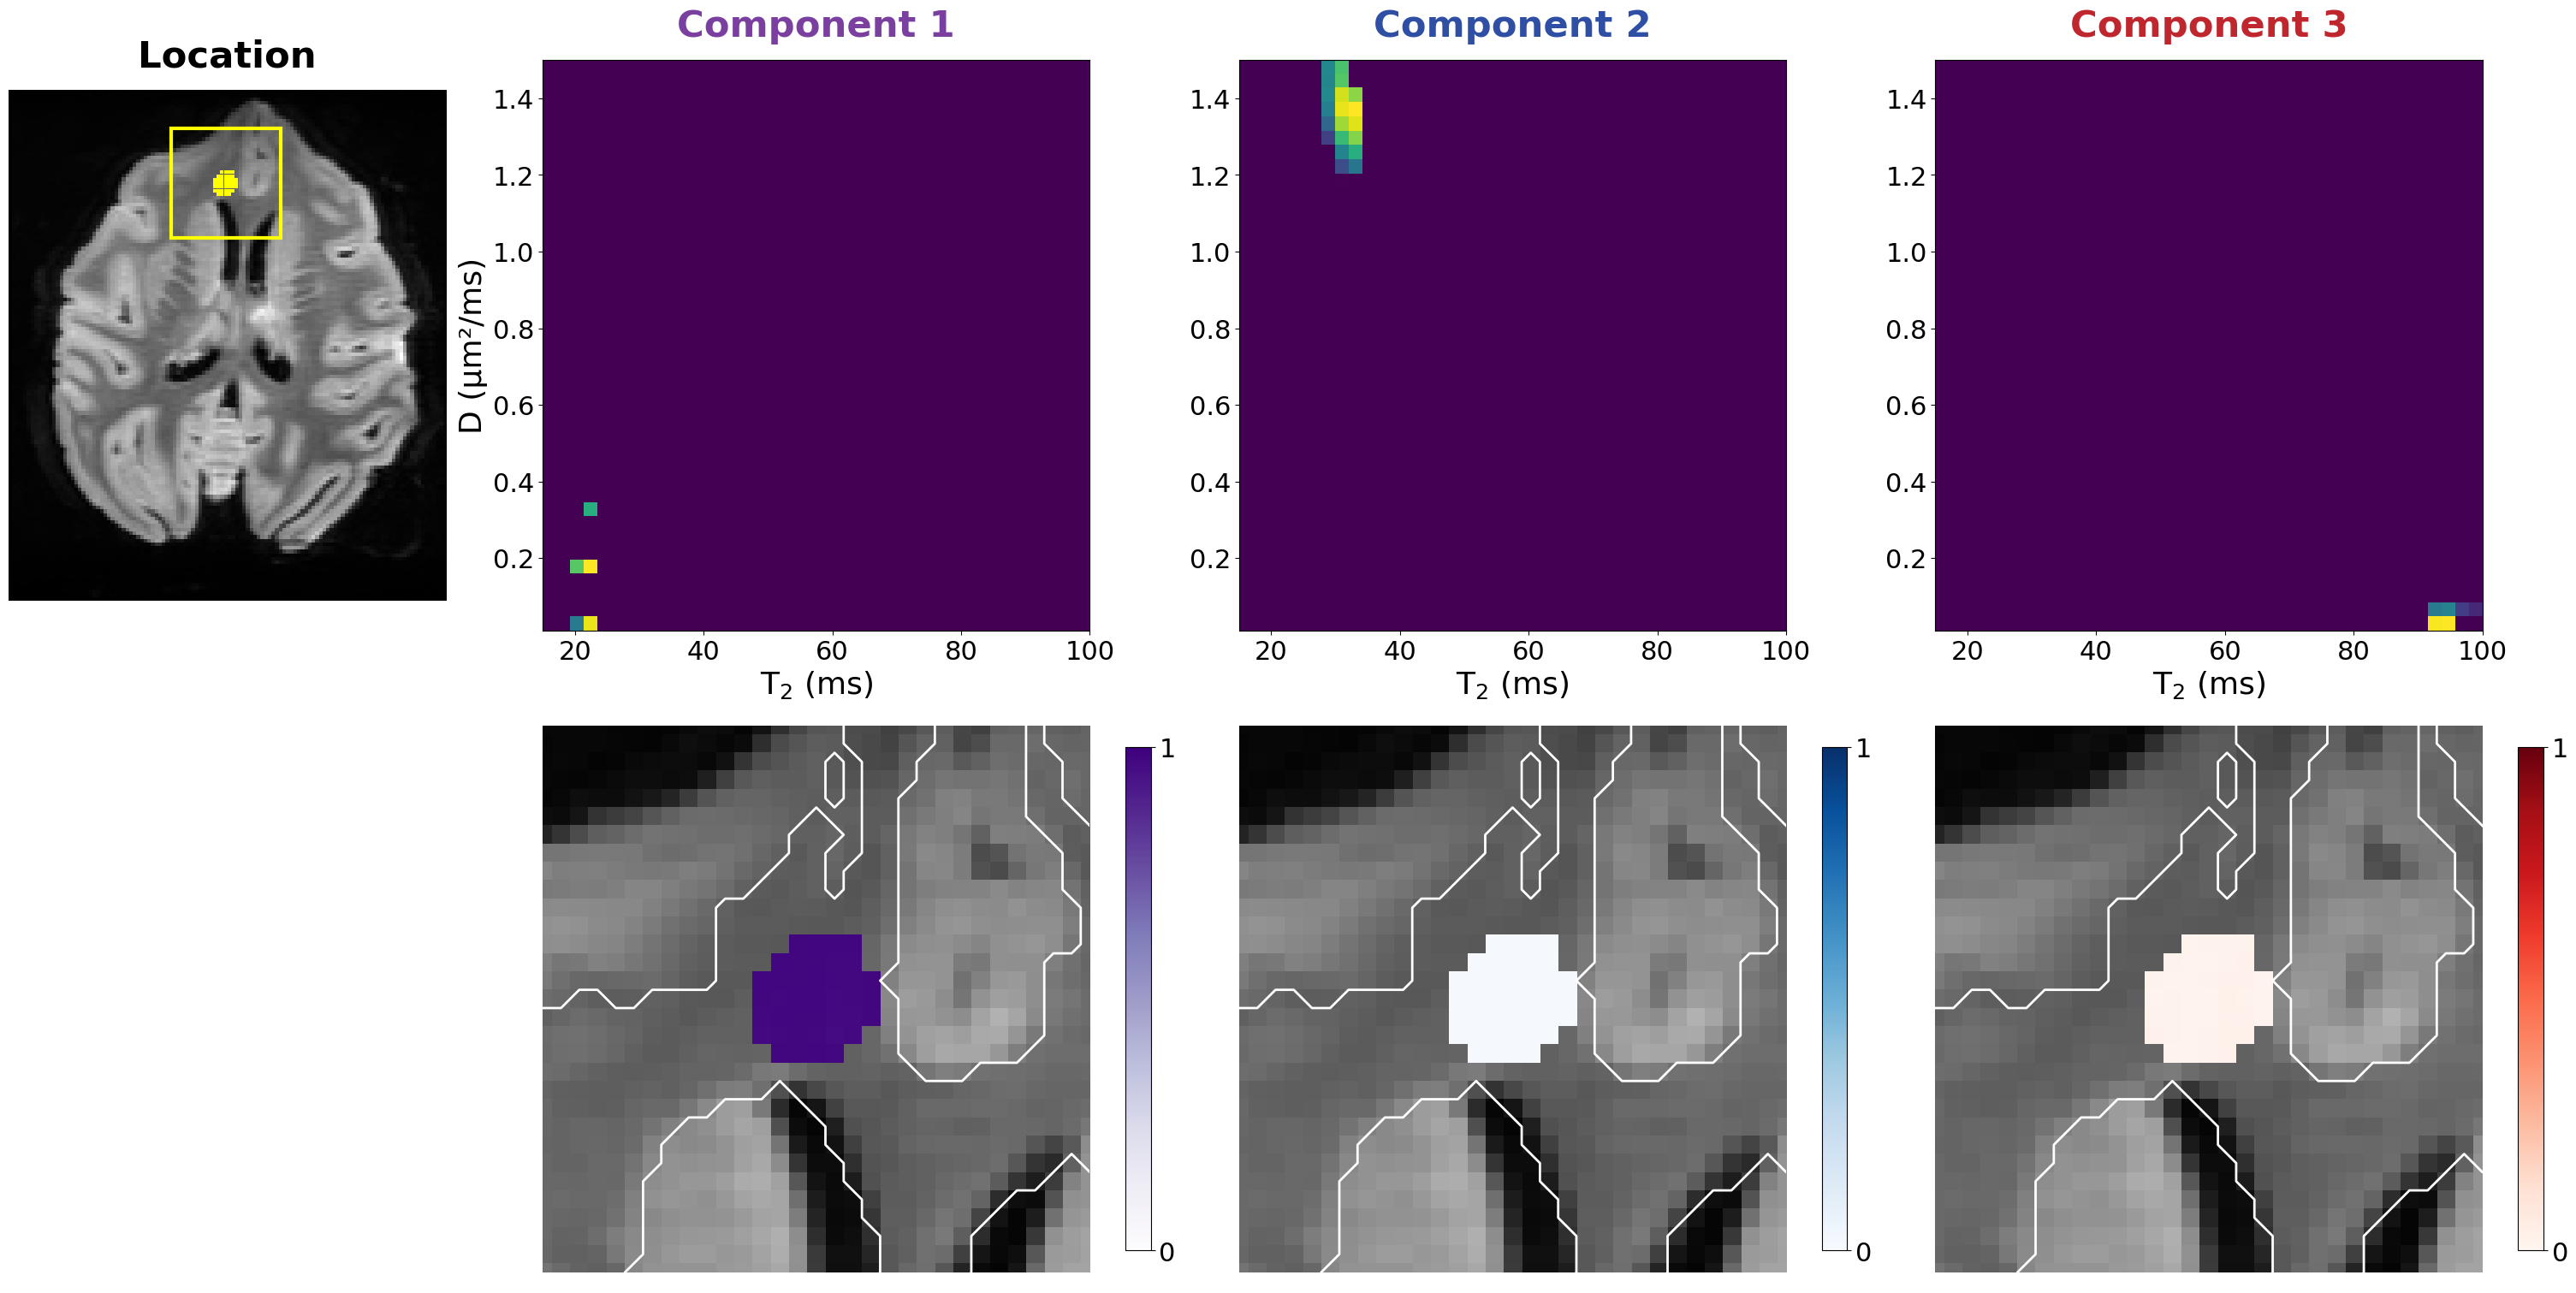

In [6]:
# ===== Corpus callosum only: K = 3 fit + poster figure =====
from matplotlib.patches import Rectangle

CMAP = "viridis"                       # colormap for the spectra (change as you like)
cx_cc, cy_cc = 59, 114                  # corpus callosum centre
n_vox_cc, K_cc = 40, 3
Dmin_cc, T2min_cc, Dmax_cc, T2max_cc, nD_cc, nT2_cc = 0.01, 15.0, 1.5, 100.0, 40, 40

# ---- grid + dictionary for this fit (separate names, so nothing else is overwritten) ----
D_cc, T2_cc = create_DT2_grid(Dmin_cc, Dmax_cc, nD_cc, T2min_cc, T2max_cc, nT2_cc)
D_vals_cc = np.linspace(Dmin_cc, Dmax_cc, nD_cc)
T2_vals_cc = np.linspace(T2min_cc, T2max_cc, nT2_cc)
b_cc, TE_cc = acq[:, 0] / 1000.0, acq[:, 1]
order_cc = np.lexsort((TE_cc, b_cc))
b_cc, TE_cc = b_cc[order_cc], TE_cc[order_cc]
A_cc = np.exp(-np.outer(b_cc, D_cc)) * np.exp(-np.outer(TE_cc, 1.0 / T2_cc))
U_cc, s_cc, V_cc = apply_SVD_to_A(A_cc, 10)

# ---- voxels ----
near = np.argsort(np.hypot(voxel_xy_all[:, 0] - cx_cc, voxel_xy_all[:, 1] - cy_cc))[:n_vox_cc]
xy_cc = voxel_xy_all[near]
Y_cc = (Y_all[:, near] / np.median(Y_all[0, near]) * 30)[order_cc]
print(f"corpus callosum: {len(xy_cc)} voxels, {mask_slice[xy_cc[:, 0], xy_cc[:, 1]].sum()} in WM")

# ---- fit ----
C0_cc, *_ = define_initial_C_NNLS(Y_cc, A_cc, range(n_vox_cc), K_cc, D_vals_cc, T2_vals_cc,
                                  Dmin_cc, Dmax_cc, T2min_cc, T2max_cc, nD_cc, nT2_cc,
                                  min_fraction=0.01, return_diagnostics=True)
Cs0_cc = project_C_to_C_small(C0_cc, s_cc, V_cc)
M0_cc = initialize_M0_monoexponential(Y_cc, np.unique(b_cc), np.unique(TE_cc))
W0_cc = initialize_W_from_C(Y_cc, U_cc, Cs0_cc, M0_cc, bound_eps=1e-3)
sig2_cc = np.mean((Y_cc - (U_cc @ Cs0_cc @ W0_cc) * M0_cc) ** 2)
W_cc, _, C_cc, *_ = run_constrained_optimisation(
    Y_cc, U_cc, s_cc, V_cc, C0_cc.copy(), M0_cc, K=K_cc, n_iter=1000, sigma2=sig2_cc, lam=1e-2,
    alpha=1.0, W=W0_cc.copy(), update_W_flag=True, update_C_flag=True, update_M0_flag=True,
    update_sigma2_flag=True, m0_prior=M0_cc, m0_prior_sigma=3, alpha_update_start=5,
    update_alpha_flag=True, weight_entropy=0.0,
    c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD_cc, nT2=nT2_cc,
    verbose_every=200)

# sort by mean T2: component 1 = shortest T2, component 3 = longest
meanT2 = (T2_cc[:, None] * C_cc).sum(0) / C_cc.sum(0)
idx = np.argsort(meanT2)
C_cc, W_cc = C_cc[:, idx], W_cc[idx]
for k in range(K_cc):
    print(f"component {k+1}: mean weight {W_cc[k].mean():.2f}, mean T2 {meanT2[idx][k]:.0f} ms")

# ---- poster figure: top = spectra, bottom = weight maps ----
fs = 26
zoom = 12
cols = ["#7B3FA0", "#2E4FA3", "#C0262D"]
cmaps = ["Purples", "Blues", "Reds"]
ext_cc = [T2_vals_cc.min(), T2_vals_cc.max(), D_vals_cc.min(), D_vals_cc.max()]
x0, x1 = xy_cc[:, 0].min() - zoom, xy_cc[:, 0].max() + zoom
y0, y1 = xy_cc[:, 1].min() - zoom, xy_cc[:, 1].max() + zoom

with plt.rc_context({"font.size": fs, "axes.labelsize": fs, "xtick.labelsize": fs - 4, "ytick.labelsize": fs - 4}):
    fig, axes = plt.subplots(2, K_cc + 1, figsize=(30, 15), constrained_layout=True,
                             gridspec_kw={"width_ratios": [0.8] + [1] * K_cc})

    # location panel (top-left), bottom-left left empty
    ax = axes[0, 0]
    ax.imshow(b0_slice.T, cmap="gray", origin="lower")
    ax.scatter(xy_cc[:, 0], xy_cc[:, 1], s=12, c="yellow", marker="s", linewidths=0)
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="yellow", linewidth=3))
    ax.set_title("Location", fontweight="bold", pad=20); ax.axis("off")
    axes[1, 0].axis("off")

    for k in range(K_cc):
        # spectrum
        ax = axes[0, k + 1]
        ax.imshow(C_cc[:, k].reshape(nD_cc, nT2_cc), origin="lower", aspect="auto", extent=ext_cc, cmap=CMAP)
        ax.set_title(f"Component {k + 1}", color=cols[k], fontweight="bold", pad=20)
        ax.set_xlabel("T$_2$ (ms)")
        if k == 0:
            ax.set_ylabel("D (µm²/ms)")

        # weight map, same 0-1 scale for every component
        wmap = np.full(mask_slice.shape, np.nan)
        wmap[xy_cc[:, 0], xy_cc[:, 1]] = W_cc[k]
        ax = axes[1, k + 1]
        ax.imshow(b0_slice.T, cmap="gray", origin="lower")
        im = ax.imshow(np.ma.masked_invalid(wmap.T), cmap=cmaps[k], vmin=0, vmax=1,
                       origin="lower", interpolation="nearest")
        ax.contour(mask_slice.T, levels=[0.5], colors="white", linewidths=2)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.axis("off")
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cb.set_ticks([0, 1])

    fig.savefig("poster_corpus_callosum_K3.png", dpi=300, bbox_inches="tight")
    plt.show()

In [7]:
grey_cc = b0_slice[xy_cc[:, 0], xy_cc[:, 1]]
for k in range(K_cc):
    r = np.corrcoef(W_cc[k], grey_cc)[0, 1]
    print(f"component {k + 1}: weight {W_cc[k].min():.2f}-{W_cc[k].max():.2f}, "
          f"mean {W_cc[k].mean():.2f}, correlation with b=0 intensity r = {r:.2f}")


component 1: weight 0.96-0.98, mean 0.97, correlation with b=0 intensity r = 0.26
component 2: weight 0.01-0.01, mean 0.01, correlation with b=0 intensity r = 0.26
component 3: weight 0.01-0.03, mean 0.02, correlation with b=0 intensity r = -0.26
